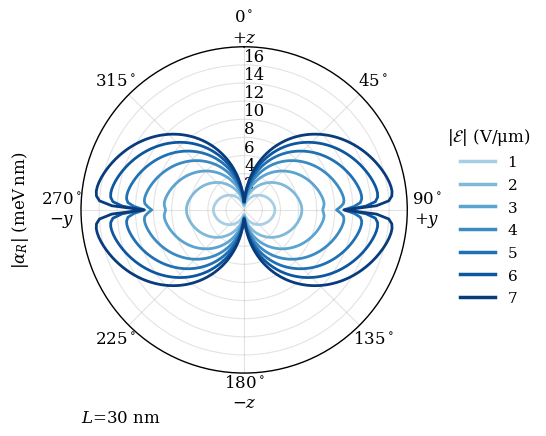

In [4]:
import matplotlib.pyplot as plt
import numpy as np


# ==============================================================
#                         PARAMETERS
# ==============================================================

N = 100
L = 300
kx = 0.001

# Electric-field magnitudes in V/micrometre
electric_fields = np.arange(1.0, 8.0, 1.0)


# ==============================================================
#                      PLOT APPEARANCE
# ==============================================================

plt.rcParams.update({
    "figure.figsize": [5.2, 4.5],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
})


def prepare_polar_axis(ax):
    """Set the angular convention for the electric-field rotation."""

    # theta = 0: E || +z
    # theta = 90 degrees: E || +y
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    angles_deg = [
        0, 45, 90, 135,
        180, 225, 270, 315,
    ]

    ax.set_xticks(np.deg2rad(angles_deg))

    ax.set_xticklabels([
        r"$0^\circ$" + "\n" + r"$+z$",
        r"$45^\circ$",
        r"$90^\circ$" + "\n" + r"$+y$",
        r"$135^\circ$",
        r"$180^\circ$" + "\n" + r"$-z$",
        r"$225^\circ$",
        r"$270^\circ$" + "\n" + r"$-y$",
        r"$315^\circ$",
    ], fontsize = 12)

    ax.grid(alpha=0.35)
    ax.spines["polar"].set_linewidth(1.0)

    # Radial range and concentric-ring labels
    ax.set_ylim(0, 18)
    ax.set_rticks(np.arange(2, 18, 2))

    # Place the radial labels along the +z axis
    ax.set_rlabel_position(0)

    # Optional: slightly separate the labels from the axis
    ax.tick_params(axis="y", pad=5, labelsize = 12)


# ==============================================================
#                 BLUE SHADES FOR ELECTRIC FIELDS
# ==============================================================

cmap = plt.get_cmap("Blues")

# Avoid the nearly white portion of the Blues colormap
blue_colors = cmap(
    np.linspace(
        0.35,
        0.95,
        len(electric_fields),
    )
)


# ==============================================================
#                  PLOT RASHBA COEFFICIENT
# ==============================================================

fig, ax = plt.subplots(
    figsize=(5.2, 4.5),
    subplot_kw={"projection": "polar"},
)

prepare_polar_axis(ax)


for E, color in zip(electric_fields, blue_colors):

    data_file = (
        f"E_rotation_N{N}_L{L}_"
        f"E{E:.2f}Vum_kx{kx}.dat"
    )

    data = np.loadtxt(
        data_file,
        comments="#",
    )

    # if data.ndim != 2 or data.shape[1] < 8:
    #     raise ValueError(
    #         f"Expected at least 8 columns in {data_file}, "
    #         f"but found shape {data.shape}."
    #     )

    theta = np.deg2rad(data[:, 0])

    # Convert alpha from eV Angstrom to meV nm
    # 1 eV Angstrom = 100 meV nm
    alpha_meV_nm = 100.0 * data[:, 3]

    # Close the polar curve when 360 degrees is not included
    angular_range = theta[-1] - theta[0]

    if not np.isclose(angular_range, 2.0 * np.pi):

        theta_plot = np.append(
            theta,
            theta[0] + 2.0 * np.pi,
        )

        alpha_plot = np.append(
            alpha_meV_nm,
            alpha_meV_nm[0],
        )

    else:
        theta_plot = theta
        alpha_plot = alpha_meV_nm

    ax.plot(
        theta_plot,
        alpha_plot,
        color=color,
        linewidth=2.0,
        label=rf"${E:g}$",
    )


# ==============================================================
#                      LABELS AND LEGEND
# ==============================================================
ax.text(0.0,-0.15,r"$L$"f"={30}" r" nm", transform=ax.transAxes,fontsize = 12)
# ax.text(0.9,-0.15,r"$k_x$"f"={kx}" r" $\AA^{-1}$", transform=ax2.transAxes,fontsize = 12)

ax.set_ylabel(
    r"$|\alpha_R|$$~(\mathrm{meV\,nm})$",
    labelpad=36, fontsize = 12
)

legend = ax.legend(
    title=r"$|\mathcal{E}|~(\mathrm{V/\mu m})$",
    loc="upper left",
    bbox_to_anchor=(1.08, 0.8),
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    handlelength=2.3,
    labelspacing=0.5,
)

# Ensure the legend lines have a clearly visible thickness
for line in legend.get_lines():
    line.set_linewidth(2.5)


# ==============================================================
#                         SAVE FIGURE
# ==============================================================

fig.tight_layout()

fig.savefig(
    f"polar_alpha_all_E_N{N}_L{L}_kx{kx}.svg",
    bbox_inches="tight",
)

fig.savefig(
    f"polar_alpha_all_E_N{N}_L{L}_kx{kx}.pdf",
    bbox_inches="tight",
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import m_e, hbar, electron_mass


# ==============================================================
#                         PARAMETERS
# ==============================================================

N = 50
L = 300
kx = 0.001
mx_eff = 0.0737

def lso(alpha):
    return hbar/(mx_eff*electron_mass * alpha)
    


# Electric-field magnitudes in V/micrometre
electric_fields = np.arange(1.0, 8.0, 1.0)


# ==============================================================
#                      PLOT APPEARANCE
# ==============================================================

plt.rcParams.update({
    "figure.figsize": [5.2, 4.5],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
})


def prepare_polar_axis(ax):
    """Set the angular convention for the electric-field rotation."""

    # theta = 0: E || +z
    # theta = 90 degrees: E || +y
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    angles_deg = [
        0, 45, 90, 135,
        180, 225, 270, 315,
    ]

    ax.set_xticks(np.deg2rad(angles_deg))

    ax.set_xticklabels([
        r"$0^\circ$" + "\n" + r"$+z$",
        r"$45^\circ$",
        r"$90^\circ$" + "\n" + r"$+y$",
        r"$135^\circ$",
        r"$180^\circ$" + "\n" + r"$-z$",
        r"$225^\circ$",
        r"$270^\circ$" + "\n" + r"$-y$",
        r"$315^\circ$",
    ], fontsize = 12)

    ax.grid(alpha=0.35)
    ax.spines["polar"].set_linewidth(1.0)

    # Radial range and concentric-ring labels
    ax.set_ylim(0, 16)
    ax.set_rticks(np.arange(2, 16, 2))

    # Place the radial labels along the +z axis
    ax.set_rlabel_position(0)

    # Optional: slightly separate the labels from the axis
    ax.tick_params(axis="y", pad=5, labelsize = 12)


# ==============================================================
#                 BLUE SHADES FOR ELECTRIC FIELDS
# ==============================================================

cmap = plt.get_cmap("Blues")

# Avoid the nearly white portion of the Blues colormap
blue_colors = cmap(
    np.linspace(
        0.35,
        0.95,
        len(electric_fields),
    )
)


# ==============================================================
#                  PLOT RASHBA COEFFICIENT
# ==============================================================

fig, ax = plt.subplots(
    figsize=(5.2, 4.5),
    subplot_kw={"projection": "polar"},
)

prepare_polar_axis(ax)


for E, color in zip(electric_fields, blue_colors):

    data_file = (
        f"E_rotation_N{N}_L{L}_"
        f"E{E:.2f}Vum_kx{kx}.dat"
    )

    data = np.loadtxt(
        data_file,
        comments="#",
    )

    if data.ndim != 2 or data.shape[1] < 8:
        raise ValueError(
            f"Expected at least 8 columns in {data_file}, "
            f"but found shape {data.shape}."
        )

    theta = np.deg2rad(data[:, 0])

    # Convert alpha from eV Angstrom to meV nm
    # 1 eV Angstrom = 100 meV nm
    alpha_meV_nm = 100.0 * data[:, 6]

    # Close the polar curve when 360 degrees is not included
    angular_range = theta[-1] - theta[0]

    if not np.isclose(angular_range, 2.0 * np.pi):

        theta_plot = np.append(
            theta,
            theta[0] + 2.0 * np.pi,
        )

        alpha_plot = np.append(
            alpha_meV_nm,
            alpha_meV_nm[0],
        )

    else:
        theta_plot = theta
        alpha_plot = alpha_meV_nm

    ax.plot(
        theta_plot,
        alpha_plot,
        color=color,
        linewidth=2.0,
        label=rf"${E:g}$",
    )


# ==============================================================
#                      LABELS AND LEGEND
# ==============================================================
ax.text(0.0,-0.15,r"$L$"f"={30}" r" nm", transform=ax2.transAxes,fontsize = 12)
# ax.text(0.9,-0.15,r"$k_x$"f"={kx}" r" $\AA^{-1}$", transform=ax2.transAxes,fontsize = 12)

ax.set_ylabel(
    r"$|\alpha_R|$$~(\mathrm{meV\,nm})$",
    labelpad=36, fontsize = 12
)

legend = ax.legend(
    title=r"$|\mathcal{E}|~(\mathrm{V/\mu m})$",
    loc="upper left",
    bbox_to_anchor=(1.08, 0.8),
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    handlelength=2.3,
    labelspacing=0.5,
)

# Ensure the legend lines have a clearly visible thickness
for line in legend.get_lines():
    line.set_linewidth(2.5)


# ==============================================================
#                         SAVE FIGURE
# ==============================================================

fig.tight_layout()

fig.savefig(
    f"polar_alpha_all_E_N{N}_L{L}_kx{kx}.svg",
    bbox_inches="tight",
)

fig.savefig(
    f"polar_alpha_all_E_N{N}_L{L}_kx{kx}.pdf",
    bbox_inches="tight",
)

plt.show()